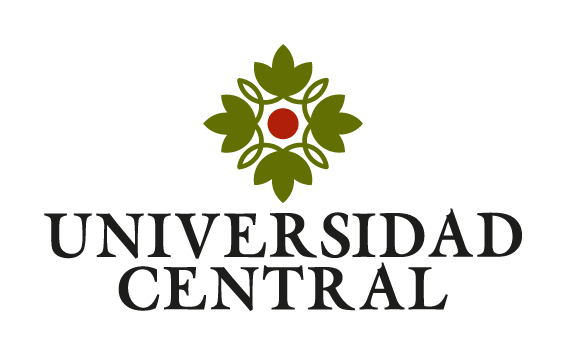

#MAESTRIA EN ANALITICA DE DATOS
---

PROCESAMIENTO DEL LENGUAJE NATURAL

Nombre: Oswaldo Salgado Gómez

Fecha: mayo 16 de 2026

Taller: Trabajo Final

# Etapa 2. Segmentación Inteligente y Generación de Embeddings

Este notebook implementa la **Etapa 2** de la arquitectura del prototipo, ahora con soporte completo para tablas.

## Pipeline
- **Entrada:** JSON normalizados en `Autos_Apertura_Json/`
- **Segmentación:**
  - Bloques jurídicos → chunks de máx. 2048 tokens con **overlap del 20% (≈410 tokens)** → `tipo_chunk='texto'`
  - Tablas anidadas + tablas globales del documento → chunks independientes → `tipo_chunk='tabla'`
  - Filtro de calidad sobre tablas antes de vectorizar
- **Embeddings:** `allenai/longformer-base-4096`, mean pooling, 768 dim
- **Salida:** en `Segmentación/`:

| Archivo | Contenido |
|---|---|
| `chunks_<nombre>.json`  | Chunks por documento (texto + tabla) con trazabilidad completa |
| `embeddings_<nombre>.npy`  | Embeddings 768-d por documento |
| `corpus_chunks_consolidado.json` | Corpus unificado para ChromaDB |
| `corpus_embeddings_consolidado.npy` | Matriz (n_total × 768) |
| `reporte_segmentacion.csv` | Estadísticas por documento (texto vs tabla) |
| `tablas_descartadas.csv` | Log de tablas filtradas por calidad (auditoría) |

## HOJA DE RUTA A SEGUIR

0.  Montar Google Drive
1.  Instalar Dependencias
2.  Instalar Librerias
3.  Configuración de Rutas
4.  Configuración de parámetros de Segmentación y Modelo
5.  Carga del Tokenizer y Modelo Longformer
6.  Limpieza de Ruido (encabezados, pies de página, OCR sucio)
7.  Filtro de Calidad para Tablas
8.  Segmentación de Bloques de Texto
9.  Segmentación de Tablas (anidadas + globales)
10. Generar Embeddings con Longformer
11. Pipeline Principal
12. Corpus Consolidado (entrada para ChromaDB en Etapa 3)
13. Reportes
14. Verificación Rápida de un Chunk (Sanity check)

#0\. Montar Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1\. Instalar Dependencias

In [ ]:
!pip install -q transformers==4.44.2 torch sentencepiece tqdm pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 111.5 MB/s eta 0:00:00


#2\. Instalar Librerias

In [ ]:
import os
import json
import glob
import uuid
import re
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import LongformerTokenizerFast, LongformerModel

#3\. Configuración de Rutas

In [ ]:
INPUT_DIR  = '/content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Autos_Apertura_Json/v4_5pdfs'
OUTPUT_DIR = '/content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Segmentación'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Entrada: {INPUT_DIR}')
print(f'Salida:  {OUTPUT_DIR}')

Entrada: /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Autos_Apertura_Json/v4_5pdfs
Salida:  /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Segmentación


# 4\. Configuración de Parámetros de Segmentación y Modelo

In [ ]:
# Segmentación de texto
CHUNK_SIZE     = 2048
OVERLAP_RATIO  = 0.20
OVERLAP_TOKENS = int(CHUNK_SIZE * OVERLAP_RATIO)   # 410
STRIDE         = CHUNK_SIZE - OVERLAP_TOKENS       # 1638

# Modelo
MODEL_NAME    = 'allenai/longformer-base-4096'
MAX_MODEL_LEN = 4096

# Filtro de calidad para tablas
MIN_CHARS_TABLA       = 30       # mínimo de chars útiles tras limpiar
MIN_TOKENS_UNICOS     = 8        # tabla con <8 tokens únicos = basura
MIN_RATIO_DIVERSIDAD  = 0.15     # tokens_únicos / total_tokens; debajo de esto = repetición OCR

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

print(f'\nCHUNK_SIZE      = {CHUNK_SIZE} tokens')
print(f'OVERLAP (20%)   = {OVERLAP_TOKENS} tokens')
print(f'STRIDE          = {STRIDE} tokens')

Dispositivo: cuda
GPU: Tesla T4

CHUNK_SIZE      = 2048 tokens
OVERLAP (20%)   = 409 tokens
STRIDE          = 1639 tokens


#5\. Carga del Tokenizer y Modelo Longformer

In [ ]:
print('Cargando tokenizer y modelo Longformer (primera vez puede tardar 1-2 min)...')
tokenizer = LongformerTokenizerFast.from_pretrained(MODEL_NAME)
model     = LongformerModel.from_pretrained(MODEL_NAME).to(device)
model.eval()
print('Modelo cargado correctamente.')

Cargando tokenizer y modelo Longformer (primera vez puede tardar 1-2 min)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

Modelo cargado correctamente.


#6\. Limpieza de Ruido (encabezados, pies de página, OCR sucio)

In [ ]:
PATRONES_RUIDO = [
    r'Oficinas:\s*Carrera\s*13\s*A.*?Email:\s*licencias.*?\.gov\.co',
    r'Centro de Orientación y Radicación de Correspondencia.*?Bogotá,?\s*D\.C\.',
    r'Línea de Orientación y Contacto Ciudadano.*?(?=\s|$)',
    r'PBX:\s*57\s*\(1\)\s*\d+',
    r'www\.anla\.gov\.co',
    r'Nit\.?:\s*900\.467\.239-2',
    r'Código Postal\s*\d+',
    r'Página\s+\d+\s+de\s+\d+',
    r'Hoja\s+No\.\s*\d+\s+de\s+\d+',
    r'Libertad\s+y\s+Orden',
]

def limpiar_texto(texto: str) -> str:
    if not texto:
        return ''
    txt = texto
    for pat in PATRONES_RUIDO:
        txt = re.sub(pat, ' ', txt, flags=re.IGNORECASE | re.DOTALL)
    txt = re.sub(r'\s+', ' ', txt).strip()
    return txt

def limpiar_markdown_tabla(markdown: str) -> str:
    """Quita fences ```, separadores |---|, y normaliza para que el embedding capte semántica."""
    if not markdown:
        return ''
    txt = markdown
    txt = re.sub(r'```[a-zA-Z]*', '', txt)         # fences ```python, ```
    txt = re.sub(r'\|[:\-\s]+\|', ' ', txt)         # filas separadoras |:---|:---|
    txt = txt.replace('|', ' ')                     # pipes
    txt = limpiar_texto(txt)
    return txt

#7\. Filtro de Calidad para Tablas

Descarta tablas con ruido OCR (markdown vacío, dimensiones 0×0, contenido muy corto, baja diversidad léxica).

In [ ]:
def tabla_es_basura(texto_limpio: str, dimensiones: dict) -> tuple:
    """Retorna (es_basura: bool, motivo: str). Aplica varias heurísticas."""
    if not texto_limpio or len(texto_limpio) < MIN_CHARS_TABLA:
        return True, f'menos_de_{MIN_CHARS_TABLA}_chars'

    # Dimensiones vacías o degeneradas
    filas = dimensiones.get('filas') if isinstance(dimensiones, dict) else None
    cols  = dimensiones.get('columnas') if isinstance(dimensiones, dict) else None
    if filas == 0 or cols == 0:
        return True, 'dimensiones_0'

    # Diversidad léxica: tokens_únicos / total_tokens
    palabras = re.findall(r'\w+', texto_limpio.lower())
    if len(palabras) < MIN_TOKENS_UNICOS:
        return True, 'pocas_palabras'
    unicas = len(set(palabras))
    if unicas < MIN_TOKENS_UNICOS:
        return True, 'pocas_palabras_unicas'
    ratio = unicas / len(palabras)
    if ratio < MIN_RATIO_DIVERSIDAD:
        return True, f'baja_diversidad_{ratio:.2f}'

    return False, 'ok'

# Test rápido
print(tabla_es_basura('cumplimiento cumplimiento cumplimiento cumplimiento cumplimiento', {'filas': 5, 'columnas': 1}))
print(tabla_es_basura('Concepto Técnico 1592 del 30 de marzo de 2022 requerimiento mantiene observación titular', {'filas': 4, 'columnas': 3}))

(True, 'pocas_palabras')
(False, 'ok')


#8\. Segmentación de Bloques de Texto

Estrategia:
1. Cada `bloque` del JSON (un numeral jurídico) se trata como unidad mínima.
2. Se tokeniza el texto del bloque (concatenando título + texto).
3. Si cabe en `CHUNK_SIZE` → 1 solo chunk.
4. Si excede → ventana deslizante con `STRIDE` = 1638 tokens, generando chunks con 20% de overlap.
5. Cada chunk hereda los metadatos del bloque original.

In [ ]:
def segmentar_bloque_texto(bloque: dict, doc_meta: dict) -> list:
    """Bloque jurídico → 1+ chunks tipo 'texto' con overlap del 20%."""
    titulo = bloque.get('titulo', '') or ''
    texto  = bloque.get('texto', '') or ''
    contenido = f'{titulo}. {texto}' if titulo else texto
    contenido = limpiar_texto(contenido)

    if not contenido or len(contenido) < 30:
        return []

    token_ids = tokenizer.encode(contenido, add_special_tokens=False)
    n_tokens  = len(token_ids)

    sub_chunks = []
    if n_tokens <= CHUNK_SIZE:
        sub_chunks.append((token_ids, contenido, 0, 1))
    else:
        idx = 0
        start = 0
        while start < n_tokens:
            end = min(start + CHUNK_SIZE, n_tokens)
            sub_ids = token_ids[start:end]
            sub_txt = tokenizer.decode(sub_ids, skip_special_tokens=True)
            sub_chunks.append((sub_ids, sub_txt, idx, None))
            idx += 1
            if end == n_tokens:
                break
            start += STRIDE
        total = len(sub_chunks)
        sub_chunks = [(t, x, i, total) for (t, x, i, _) in sub_chunks]

    out = []
    for token_ids_c, texto_c, idx_c, total_c in sub_chunks:
        out.append({
            'chunk_id': str(uuid.uuid4()),
            'tipo_chunk': 'texto',
            'id_documento': doc_meta['id_documento'],
            'filename': doc_meta['filename'],
            'tipo_documento': doc_meta.get('tipo_documento'),
            'numero_documento': doc_meta.get('numero_documento'),
            'fecha_documento': doc_meta.get('fecha_documento'),
            'bloque_id': bloque.get('id'),
            'bloque_id_padre': None,           # solo aplica a tablas anidadas
            'numeral': bloque.get('numeral'),
            'tipo_numeral': bloque.get('tipo_numeral'),
            'nivel': bloque.get('nivel'),
            'titulo_bloque': titulo,
            'pagina_inicio': bloque.get('pagina_inicio'),
            'pagina_fin': bloque.get('pagina_fin'),
            'tabla_id': None,
            'tabla_fuente': None,
            'tabla_dimensiones': None,
            'chunk_index': idx_c,
            'total_chunks_bloque': total_c,
            'n_tokens': len(token_ids_c),
            'texto': texto_c,
            'token_ids': token_ids_c,
        })
    return out

# 9\. Segmentación de Tablas (anidadas + globales)

Cada tabla válida → 1 chunk `tipo_chunk='tabla'`. Si el markdown de la tabla excede 2048 tokens, se divide con el mismo overlap del 20%.

In [ ]:
def segmentar_tabla(tabla: dict, doc_meta: dict, bloque_padre: dict = None) -> tuple:
    """
    Devuelve (lista_chunks, motivo_descarte).
    bloque_padre: None para tablas globales; dict del bloque para tablas anidadas.
    """
    markdown = tabla.get('markdown', '') or ''
    titulo_tabla = tabla.get('titulo', '') or ''
    dimensiones  = tabla.get('dimensiones', {}) or {}

    # Limpieza
    contenido = limpiar_markdown_tabla(markdown)
    if titulo_tabla:
        contenido = f'{titulo_tabla}. {contenido}'

    # Filtro de calidad
    basura, motivo = tabla_es_basura(contenido, dimensiones)
    if basura:
        return [], motivo

    # Tokenizar
    token_ids = tokenizer.encode(contenido, add_special_tokens=False)
    n_tokens  = len(token_ids)

    sub_chunks = []
    if n_tokens <= CHUNK_SIZE:
        sub_chunks.append((token_ids, contenido, 0, 1))
    else:
        idx = 0
        start = 0
        while start < n_tokens:
            end = min(start + CHUNK_SIZE, n_tokens)
            sub_ids = token_ids[start:end]
            sub_txt = tokenizer.decode(sub_ids, skip_special_tokens=True)
            sub_chunks.append((sub_ids, sub_txt, idx, None))
            idx += 1
            if end == n_tokens:
                break
            start += STRIDE
        total = len(sub_chunks)
        sub_chunks = [(t, x, i, total) for (t, x, i, _) in sub_chunks]

    bloque_padre_id = bloque_padre.get('id') if bloque_padre else None
    numeral_padre   = bloque_padre.get('numeral') if bloque_padre else tabla.get('seccion')
    titulo_padre    = bloque_padre.get('titulo') if bloque_padre else tabla.get('titulo')
    pagina_ini      = bloque_padre.get('pagina_inicio') if bloque_padre else tabla.get('pagina')
    pagina_fin      = bloque_padre.get('pagina_fin') if bloque_padre else tabla.get('pagina')

    out = []
    for token_ids_c, texto_c, idx_c, total_c in sub_chunks:
        out.append({
            'chunk_id': str(uuid.uuid4()),
            'tipo_chunk': 'tabla',
            'id_documento': doc_meta['id_documento'],
            'filename': doc_meta['filename'],
            'tipo_documento': doc_meta.get('tipo_documento'),
            'numero_documento': doc_meta.get('numero_documento'),
            'fecha_documento': doc_meta.get('fecha_documento'),
            'bloque_id': None,
            'bloque_id_padre': bloque_padre_id,   # clave para parent-document retrieval
            'numeral': numeral_padre,
            'tipo_numeral': bloque_padre.get('tipo_numeral') if bloque_padre else 'tabla_global',
            'nivel': bloque_padre.get('nivel') if bloque_padre else None,
            'titulo_bloque': titulo_padre,
            'pagina_inicio': pagina_ini,
            'pagina_fin': pagina_fin,
            'tabla_id': tabla.get('id'),
            'tabla_fuente': tabla.get('fuente'),       # html | preformateado | pdfplumber
            'tabla_dimensiones': dimensiones,
            'chunk_index': idx_c,
            'total_chunks_bloque': total_c,
            'n_tokens': len(token_ids_c),
            'texto': texto_c,
            'token_ids': token_ids_c,
        })
    return out, 'ok'

#10\. Generar Embeddings con Longformer


In [ ]:
def generar_embedding(token_ids: list) -> np.ndarray:
    ids = [tokenizer.cls_token_id] + list(token_ids) + [tokenizer.sep_token_id]
    if len(ids) > MAX_MODEL_LEN:
        ids = ids[:MAX_MODEL_LEN]

    input_ids = torch.tensor([ids], device=device)
    attention_mask = torch.ones_like(input_ids)
    global_attention_mask = torch.zeros_like(input_ids)
    global_attention_mask[:, 0] = 1

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            global_attention_mask=global_attention_mask,
        )
    last_hidden = outputs.last_hidden_state
    mask = attention_mask.unsqueeze(-1).float()
    summed = (last_hidden * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return (summed / counts).squeeze(0).cpu().numpy().astype(np.float32)

#11\. Pipeline Principal

In [ ]:
archivos_json = sorted(glob.glob(os.path.join(INPUT_DIR, '*.json')))
print(f'JSON encontrados: {len(archivos_json)}')
for f in archivos_json:
    print(f'  - {os.path.basename(f)}')

JSON encontrados: 5
  - 2554_1092_2023-02-28.json
  - 2799_3668_2024-05-27.json
  - 2824_2702_2024-04-26.json
  - 2826_2449_2024-04-18.json
  - 2844_1451_2024-03-18.json


In [ ]:
corpus_chunks = []
corpus_embeddings = []
reporte_filas = []
tablas_descartadas_log = []

for ruta_json in archivos_json:
    nombre = os.path.basename(ruta_json).replace('.json', '')
    print(f'\n{"=" * 70}\nProcesando: {nombre}\n{"=" * 70}')

    with open(ruta_json, 'r', encoding='utf-8') as f:
        doc = json.load(f)

    doc_meta = {
        'id_documento': doc.get('id_documento'),
        'filename': doc.get('filename'),
        'tipo_documento': doc.get('tipo_documento'),
        'numero_documento': doc.get('numero_documento'),
        'fecha_documento': doc.get('fecha_documento'),
    }

    bloques = doc.get('bloques', [])
    tablas_globales = doc.get('tablas', [])
    print(f'Bloques: {len(bloques)}  |  Tablas globales: {len(tablas_globales)}')

    chunks_doc = []
    tablas_ok = 0
    tablas_descartadas = 0

    # 1. Bloques de texto + tablas anidadas
    for bloque in tqdm(bloques, desc='Bloques'):
        chunks_doc.extend(segmentar_bloque_texto(bloque, doc_meta))

        for tabla in bloque.get('tablas_anidadas', []) or []:
            chunks_tabla, motivo = segmentar_tabla(tabla, doc_meta, bloque_padre=bloque)
            if chunks_tabla:
                chunks_doc.extend(chunks_tabla)
                tablas_ok += 1
            else:
                tablas_descartadas += 1
                tablas_descartadas_log.append({
                    'archivo': nombre, 'tabla_id': tabla.get('id'),
                    'tipo': 'anidada', 'motivo': motivo,
                })

    # 2. Tablas globales del documento
    for tabla in tqdm(tablas_globales, desc='Tablas globales'):
        chunks_tabla, motivo = segmentar_tabla(tabla, doc_meta, bloque_padre=None)
        if chunks_tabla:
            chunks_doc.extend(chunks_tabla)
            tablas_ok += 1
        else:
            tablas_descartadas += 1
            tablas_descartadas_log.append({
                'archivo': nombre, 'tabla_id': tabla.get('id'),
                'tipo': 'global', 'motivo': motivo,
            })

    print(f'Chunks generados: {len(chunks_doc)}  '
          f'(texto: {sum(1 for c in chunks_doc if c["tipo_chunk"]=="texto")}, '
          f'tabla: {sum(1 for c in chunks_doc if c["tipo_chunk"]=="tabla")})')
    print(f'Tablas: {tablas_ok} OK, {tablas_descartadas} descartadas por filtro de calidad')

    if not chunks_doc:
        print('⚠ Sin chunks, se omite documento.')
        continue

    # 3. Embeddings
    embeddings_doc = np.zeros((len(chunks_doc), 768), dtype=np.float32)
    for i, ch in enumerate(tqdm(chunks_doc, desc='Embeddings')):
        embeddings_doc[i] = generar_embedding(ch['token_ids'])

    # 4. Guardado por documento
    chunks_serializables = [{k: v for k, v in ch.items() if k != 'token_ids'} for ch in chunks_doc]

    ruta_chunks = os.path.join(OUTPUT_DIR, f'chunks_{nombre}.json')
    with open(ruta_chunks, 'w', encoding='utf-8') as f:
        json.dump({
            'documento': doc_meta,
            'parametros': {
                'modelo': MODEL_NAME,
                'chunk_size_tokens': CHUNK_SIZE,
                'overlap_ratio': OVERLAP_RATIO,
                'overlap_tokens': OVERLAP_TOKENS,
                'stride': STRIDE,
                'min_chars_tabla': MIN_CHARS_TABLA,
                'min_tokens_unicos': MIN_TOKENS_UNICOS,
                'min_ratio_diversidad': MIN_RATIO_DIVERSIDAD,
            },
            'total_chunks': len(chunks_serializables),
            'chunks': chunks_serializables,
        }, f, ensure_ascii=False, indent=2)

    ruta_emb = os.path.join(OUTPUT_DIR, f'embeddings_{nombre}.npy')
    np.save(ruta_emb, embeddings_doc)

    print(f'✓ {ruta_chunks}')
    print(f'✓ {ruta_emb}  shape={embeddings_doc.shape}')

    corpus_chunks.extend(chunks_serializables)
    corpus_embeddings.append(embeddings_doc)

    reporte_filas.append({
        'archivo': nombre,
        'bloques_originales': len(bloques),
        'tablas_globales_originales': len(tablas_globales),
        'chunks_texto': sum(1 for c in chunks_doc if c['tipo_chunk']=='texto'),
        'chunks_tabla': sum(1 for c in chunks_doc if c['tipo_chunk']=='tabla'),
        'chunks_total': len(chunks_doc),
        'tablas_ok': tablas_ok,
        'tablas_descartadas': tablas_descartadas,
        'tokens_promedio': round(np.mean([c['n_tokens'] for c in chunks_doc]), 1),
        'tokens_max': max(c['n_tokens'] for c in chunks_doc),
    })


Procesando: 2554_1092_2023-02-28
Bloques: 21  |  Tablas globales: 0


Bloques:   0%|          | 0/21 [00:00<?, ?it/s]

Tablas globales: 0it [00:00, ?it/s]

Chunks generados: 23  (texto: 23, tabla: 0)
Tablas: 0 OK, 0 descartadas por filtro de calidad


Embeddings:   0%|          | 0/23 [00:00<?, ?it/s]

...

Bloques:   0%|          | 0/16 [00:00<?, ?it/s]

Tablas globales:   0%|          | 0/3 [00:00<?, ?it/s]

Chunks generados: 22  (texto: 16, tabla: 6)
Tablas: 6 OK, 0 descartadas por filtro de calidad


Embeddings:   0%|          | 0/22 [00:00<?, ?it/s]

✓ /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Segmentación/chunks_2844_1451_2024-03-18.json
✓ /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Segmentación/embeddings_2844_1451_2024-03-18.npy  shape=(22, 768)


#12\. Corpus Consolidado (entrada para ChromaDB en Etapa 3)

In [ ]:
if corpus_embeddings:
    corpus_matrix = np.vstack(corpus_embeddings)

    ruta_corpus_json = os.path.join(OUTPUT_DIR, 'corpus_chunks_consolidado.json')
    with open(ruta_corpus_json, 'w', encoding='utf-8') as f:
        json.dump({
            'parametros': {
                'modelo': MODEL_NAME,
                'chunk_size_tokens': CHUNK_SIZE,
                'overlap_ratio': OVERLAP_RATIO,
                'overlap_tokens': OVERLAP_TOKENS,
            },
            'total_documentos': len(archivos_json),
            'total_chunks': len(corpus_chunks),
            'chunks_texto': sum(1 for c in corpus_chunks if c['tipo_chunk']=='texto'),
            'chunks_tabla': sum(1 for c in corpus_chunks if c['tipo_chunk']=='tabla'),
            'dim_embedding': int(corpus_matrix.shape[1]),
            'chunks': corpus_chunks,
        }, f, ensure_ascii=False, indent=2)

    ruta_corpus_npy = os.path.join(OUTPUT_DIR, 'corpus_embeddings_consolidado.npy')
    np.save(ruta_corpus_npy, corpus_matrix)

    print(f'✓ {ruta_corpus_json}')
    print(f'✓ {ruta_corpus_npy}  shape={corpus_matrix.shape}')

✓ /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Segmentación/corpus_chunks_consolidado.json
✓ /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Segmentación/corpus_embeddings_consolidado.npy  shape=(139, 768)


# 13\. Reportes

In [ ]:
# Reporte principal
df_reporte = pd.DataFrame(reporte_filas)
ruta_reporte = os.path.join(OUTPUT_DIR, 'reporte_segmentacion.csv')
df_reporte.to_csv(ruta_reporte, index=False, encoding='utf-8')
print(f'✓ {ruta_reporte}\n')
df_reporte

✓ /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Segmentación/reporte_segmentacion.csv



,archivo,bloques_originales,tablas_globales_originales,chunks_texto,chunks_tabla,chunks_total,tablas_ok,tablas_descartadas,tokens_promedio,tokens_max
0,2554_1092_2023-02-28,21,0,23,0,23,0,0,622.0,2048
1,2799_3668_2024-05-27,9,7,13,14,27,14,0,733.0,2048
2,2824_2702_2024-04-26,13,6,16,12,28,12,0,851.4,2048
3,2826_2449_2024-04-18,15,12,15,24,39,24,0,490.4,1994
4,2844_1451_2024-03-18,16,3,16,6,22,6,0,522.7,1871


In [ ]:
# Log de tablas descartadas (útil para debugging)
if tablas_descartadas_log:
    df_descartes = pd.DataFrame(tablas_descartadas_log)
    ruta_descartes = os.path.join(OUTPUT_DIR, 'tablas_descartadas.csv')
    df_descartes.to_csv(ruta_descartes, index=False, encoding='utf-8')
    print(f'✓ {ruta_descartes}')
    print(f'\nMotivos de descarte:')
    print(df_descartes['motivo'].value_counts())
else:
    print('No hubo tablas descartadas.')

No hubo tablas descartadas.


In [ ]:
# Resumen global
if reporte_filas:
    print('=' * 60)
    print('RESUMEN GLOBAL — ETAPA 2')
    print('=' * 60)
    print(f'Documentos:                      {len(df_reporte)}')
    print(f'Bloques jurídicos:               {df_reporte["bloques_originales"].sum()}')
    print(f'Tablas originales (globales):    {df_reporte["tablas_globales_originales"].sum()}')
    print(f'Chunks de texto:                 {df_reporte["chunks_texto"].sum()}')
    print(f'Chunks de tabla:                 {df_reporte["chunks_tabla"].sum()}')
    print(f'Chunks totales (entrada RAG):    {df_reporte["chunks_total"].sum()}')
    print(f'Tablas válidas:                  {df_reporte["tablas_ok"].sum()}')
    print(f'Tablas descartadas por filtro:   {df_reporte["tablas_descartadas"].sum()}')
    print(f'Modelo:                          {MODEL_NAME}')
    print(f'Dim. embedding:                  768')
    print(f'Overlap:                         {OVERLAP_RATIO*100:.0f}% ({OVERLAP_TOKENS} tokens)')

RESUMEN GLOBAL — ETAPA 2
Documentos:                      5
Bloques jurídicos:               74
Tablas originales (globales):    28
Chunks de texto:                 83
Chunks de tabla:                 56
Chunks totales (entrada RAG):    139
Tablas válidas:                  56
Tablas descartadas por filtro:   0
Modelo:                          allenai/longformer-base-4096
Dim. embedding:                  768
Overlap:                         20% (409 tokens)


#14\. Verificación Rápida de un Chunk (Sanity check)

In [ ]:
if corpus_chunks:
    # Un chunk de texto y uno de tabla
    ej_texto = next((c for c in corpus_chunks if c['tipo_chunk']=='texto'), None)
    ej_tabla = next((c for c in corpus_chunks if c['tipo_chunk']=='tabla'), None)

    for label, ej in [('TEXTO', ej_texto), ('TABLA', ej_tabla)]:
        if ej is None:
            continue
        print(f'\n--- Ejemplo chunk {label} ---')
        for k, v in ej.items():
            if k == 'texto':
                print(f'{k}: {str(v)[:250]}...')
            else:
                print(f'{k}: {v}')


--- Ejemplo chunk TEXTO ---
chunk_id: 4926205b-4f18-4394-bce7-4c36a1d3096a
tipo_chunk: texto
id_documento: 4caa3a79-ffd2-44e2-bbcb-7918f4798f6f
filename: 2554_1092_2023-02-28.pdf
tipo_documento: AUTO
numero_documento: 1092
fecha_documento: 2023-02-28
bloque_id: 3d5d1a7e-e2f3-47c8-8e99-37fad3a03124
bloque_id_padre: None
numeral: INTRO
tipo_numeral: intro
nivel: 0
titulo_bloque: ENCABEZADO Y PROEMIO
pagina_inicio: 1
pagina_fin: 1
tabla_id: None
tabla_fuente: None
tabla_dimensiones: None
chunk_index: 0
total_chunks_bloque: 1
n_tokens: 276
texto: ENCABEZADO Y PROEMIO. República de Colombia Ministerio de Ambiente y Desarrollo Sostenible AUTORIDAD NACIONAL DE LICENCIAS AMBIENTALES - ANLA – AUTO N° 01092 ( 28 de febrero de 2023 ) “POR EL CUAL SE ORDENA EL INICIO DE UN PROCEDIMIENTO SANCIONATORIO...

--- Ejemplo chunk TABLA ---
chunk_id: e7893b0b-f0e0-49c1-a93d-866e9d543f31
tipo_chunk: tabla
id_documento: 57e84c2c-8d63-4005-a256-7493faf8c059
filename: 2799_3668_2024-05-27.pdf
tipo_documento: 